# 📘 Session 15: Full EDA End-to-End Demo Project
### Duration: ~3 Hours

---

**Project:** Palmer Penguins — Exploratory Data Analysis Report

**Business / research questions:**
1. How complete and trustworthy is the dataset?
2. How do body measurements differ across **species**, **sex**, and **island**?
3. Which measurements are most associated with each other?
4. What cleaning steps and modeling notes should we hand off to the next phase?

---

**Workflow (from Session 14):**
```
Context → Load → Quality audit → Clean → Univariate → Bivariate → Multivariate → Report
```

**Why this capstone matters:**
- Applies **Sessions 11–14** in one coherent narrative
- Mirrors a real analyst deliverable: **plots + written conclusions + action list**
- Uses a dataset with **missing values** and **natural segments** — not a toy-perfect table

> This is a **demo project**, not production code. Focus on the **process** and **documentation**, not perfect automation.

**Libraries:** `pandas`, `numpy`, `matplotlib`, `seaborn`


---
## Step 0 — Project context

| Item | Detail |
|------|--------|
| **Dataset** | Palmer Penguins (`sns.load_dataset('penguins')`) |
| **Source** | Built into Seaborn; based on field measurements |
| **Row grain** | One row = one penguin observation |
| **Target (for future modeling)** | `species` (classification) or any measurement (regression) |
| **Segments** | `island`, `sex`, `species` |

### Success criteria for this EDA

- [ ] Quality issues documented with counts
- [ ] Clean analysis-ready table defined (and row count noted)
- [ ] Every numeric feature profiled (distribution + outliers)
- [ ] Key relationships explored by species/sex
- [ ] Final **EDA report** section completed


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")

# Reproducibility for any simulated additions
RNG = np.random.default_rng(42)

raw = sns.load_dataset("penguins")
print("Raw shape:", raw.shape)
print("\nColumns:", list(raw.columns))
raw.head()


Raw shape: (344, 7)

Columns: ['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


---
## Step 1 — Data quality audit

Run the same audit mindset as Session 14 before any plots.


In [2]:
def audit_frame(df):
    return (
        pd.DataFrame({
            "dtype": df.dtypes.astype(str),
            "non_null": df.notna().sum(),
            "missing_pct": (df.isna().mean() * 100).round(2),
            "nunique": df.nunique(),
        })
        .sort_values("missing_pct", ascending=False)
    )

print("=== AUDIT REPORT ===")
print(audit_frame(raw))
print("\nDuplicate rows:", raw.duplicated().sum())
print("\nSpecies counts:\n", raw["species"].value_counts())
print("\nMissing by species:\n", raw.groupby("species", observed=True).apply(lambda g: g.isna().any(axis=1).sum()))


=== AUDIT REPORT ===
                     dtype  non_null  missing_pct  nunique
sex                    str       333         3.20        2
bill_depth_mm      float64       342         0.58       80
bill_length_mm     float64       342         0.58      164
flipper_length_mm  float64       342         0.58       55
body_mass_g        float64       342         0.58       94
island                 str       344         0.00        3
species                str       344         0.00        3

Duplicate rows: 0

Species counts:
 species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

Missing by species:
 species
Adelie       6
Chinstrap    0
Gentoo       5
dtype: int64


### Quality findings (fill as you run)

| Issue | Severity | Action |
|-------|----------|--------|
| Missing values in `sex` and some measurements | Medium | Drop rows with missing **modeling-critical** cols or impute later |
| Only 3 species, 3 islands | Info | Good for teaching segmentation |
| Small sample (~340 rows) | Info | Avoid over-interpreting tiny subgroup counts |

> ⚠️ **Decision for this project:** Build `df` = rows with **complete numeric measurements + species + sex** for the main analysis. Document how many rows we drop.


In [3]:
# --- Cleaning decisions ---
MODEL_COLS = [
    "species", "island", "sex",
    "bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g",
]

df = raw.dropna(subset=MODEL_COLS).copy()
df["sex"] = df["sex"].astype("category")
df["species"] = df["species"].astype("category")
df["island"] = df["island"].astype("category")

# Engineered ratio (EDA feature idea)
df["bill_ratio"] = df["bill_length_mm"] / df["bill_depth_mm"]

print(f"Rows: {len(raw)} → {len(df)} after dropna ({len(raw) - len(df)} removed)")
print("\nCleaned species balance:\n", df["species"].value_counts(normalize=True).round(3))
df.describe().T


Rows: 344 → 333 after dropna (11 removed)

Cleaned species balance:
 species
Adelie       0.438
Gentoo       0.357
Chinstrap    0.204
Name: proportion, dtype: float64


,count,mean,std,min,25%,50%,75%,max
bill_length_mm,333.0,43.992793,5.468668,32.10000,39.500000,44.500000,48.60000,59.600000
bill_depth_mm,333.0,17.164865,1.969235,13.10000,15.600000,17.300000,18.70000,21.500000
flipper_length_mm,333.0,200.966967,14.015765,172.00000,190.000000,197.000000,213.00000,231.000000
body_mass_g,333.0,4207.057057,805.215802,2700.00000,3550.000000,4050.000000,4775.00000,6300.000000
bill_ratio,333.0,2.607228,0.495436,1.63981,2.162651,2.576531,3.09697,3.612676


---
## Step 2 — Univariate EDA

Profile **each** measurement and key categoricals. Save one dashboard figure for the report.


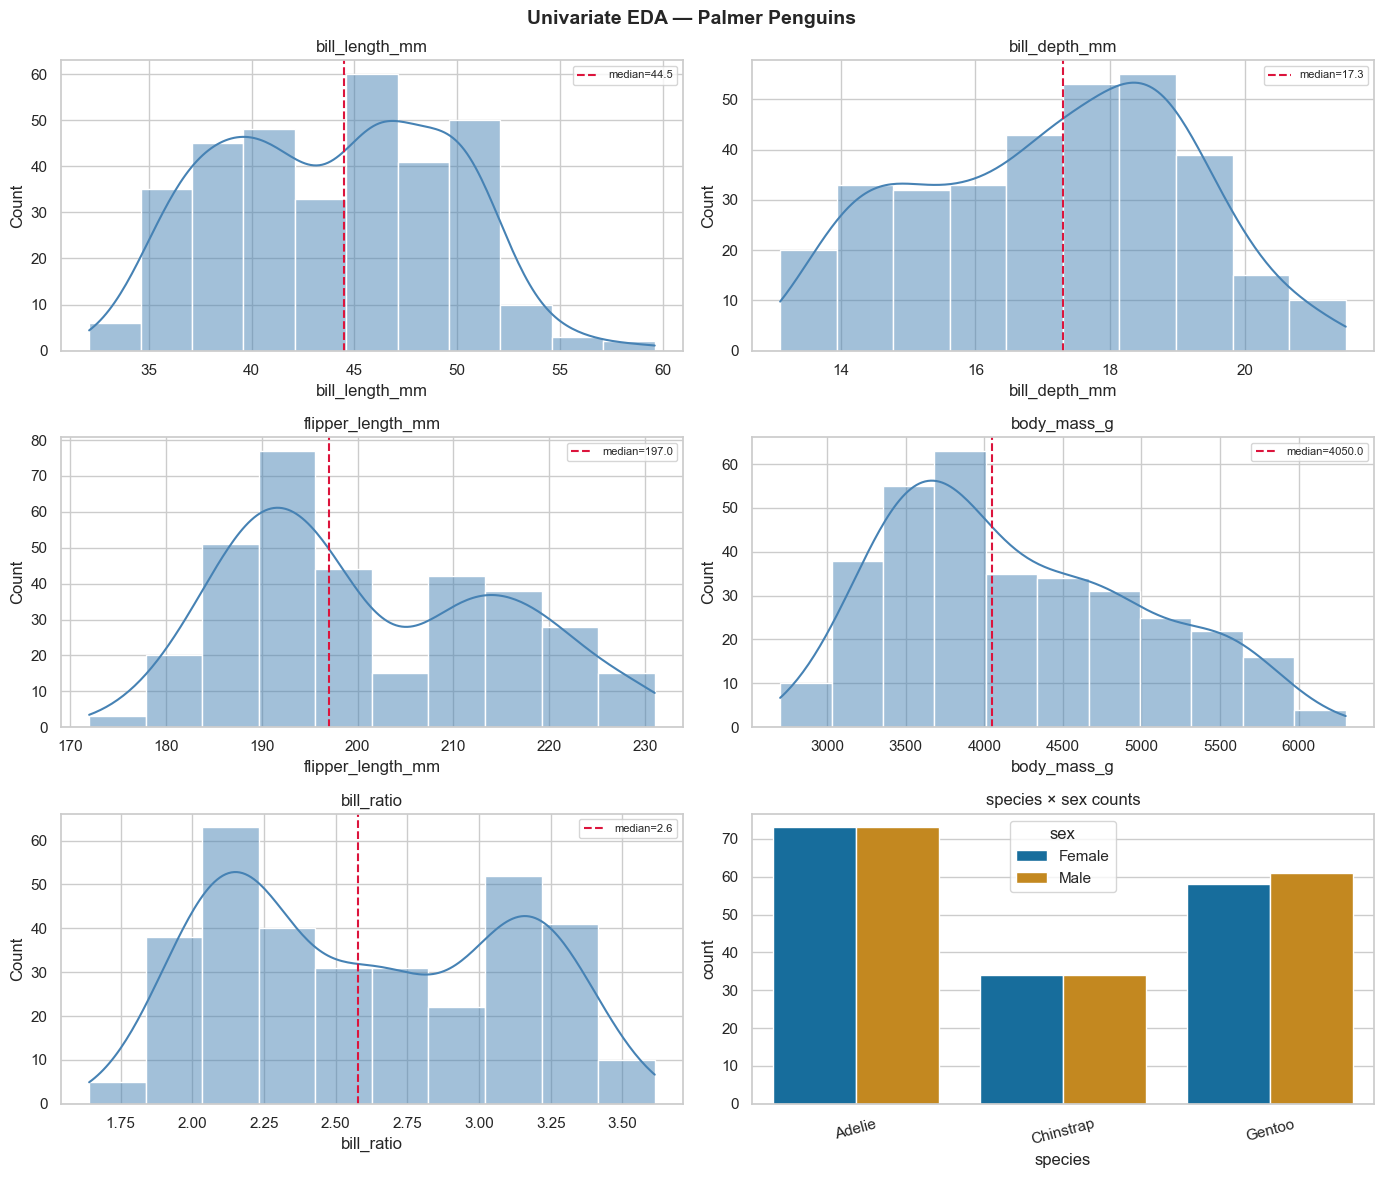

Saved: penguin_eda_univariate.png


In [4]:
NUM = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g", "bill_ratio"]

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.ravel()

for ax, col in zip(axes[: len(NUM)], NUM):
    sns.histplot(data=df, x=col, kde=True, ax=ax, color="steelblue", edgecolor="white")
    ax.axvline(df[col].median(), color="crimson", ls="--", label=f"median={df[col].median():.1f}")
    ax.legend(fontsize=8)
    ax.set_title(col)

# Categorical panels
sns.countplot(data=df, x="species", hue="sex", ax=axes[5])
axes[5].set_title("species × sex counts")
axes[5].tick_params(axis="x", rotation=15)

plt.suptitle("Univariate EDA — Palmer Penguins", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("penguin_eda_univariate.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: penguin_eda_univariate.png")


**Univariate takeaways (example — verify from your outputs):**
- Measurements are **roughly bell-shaped** within species but **multimodal** when pooled (because species differ in size).
- **Adelie** is the most frequent species in this sample.
- `bill_ratio` may separate species better than raw bill length alone — test in bivariate section.


---
## Step 3 — Bivariate & segmented EDA

Compare measurements across **species** and **sex**. This is where biological structure usually appears.


Body mass (g) by species × sex:
                   median    mean  count
species   sex                          
Adelie    Female  3400.0  3368.8     73
          Male    4000.0  4043.5     73
Chinstrap Female  3550.0  3527.2     34
          Male    3950.0  3939.0     34
Gentoo    Female  4700.0  4679.7     58
          Male    5500.0  5484.8     61


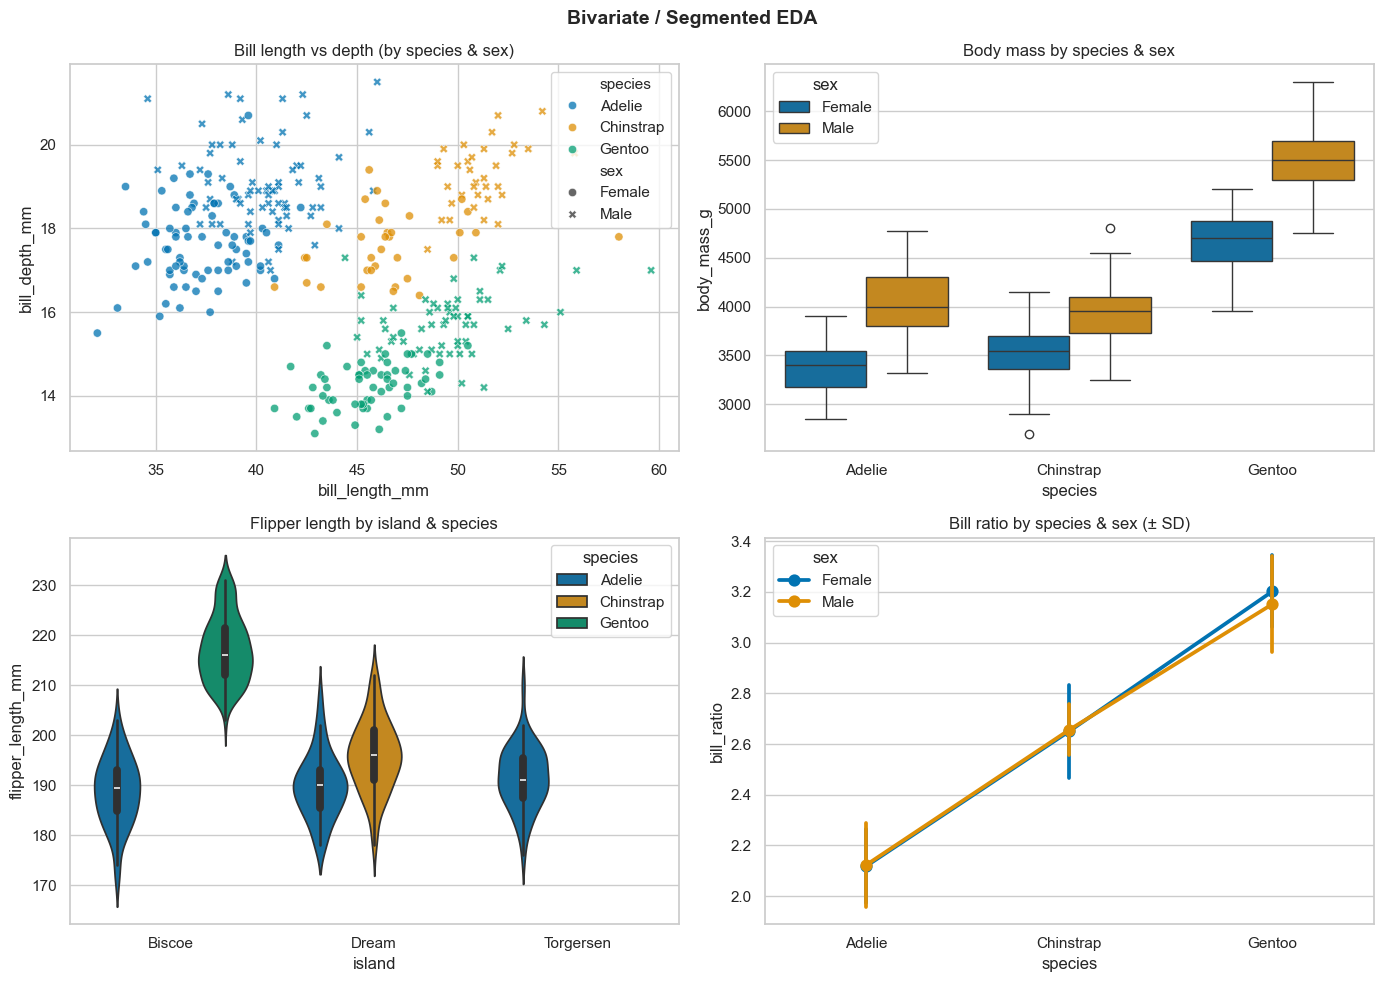

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.scatterplot(
    data=df, x="bill_length_mm", y="bill_depth_mm",
    hue="species", style="sex", alpha=0.75, ax=axes[0, 0],
)
axes[0, 0].set_title("Bill length vs depth (by species & sex)")

sns.boxplot(data=df, x="species", y="body_mass_g", hue="sex", ax=axes[0, 1])
axes[0, 1].set_title("Body mass by species & sex")

sns.violinplot(data=df, x="island", y="flipper_length_mm", hue="species", split=False, ax=axes[1, 0])
axes[1, 0].set_title("Flipper length by island & species")

# Segment table: median body mass
seg = (
    df.groupby(["species", "sex"], observed=True)["body_mass_g"]
    .agg(["median", "mean", "count"])
    .round(1)
)
print("Body mass (g) by species × sex:\n", seg)

sns.pointplot(data=df, x="species", y="bill_ratio", hue="sex", errorbar="sd", ax=axes[1, 1])
axes[1, 1].set_title("Bill ratio by species & sex (± SD)")

plt.suptitle("Bivariate / Segmented EDA", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("penguin_eda_bivariate.png", dpi=150, bbox_inches="tight")
plt.show()


**Bivariate takeaways:**
- **`bill_length_mm` vs `bill_depth_mm`** separates **Gentoo** from Adelie/Chinstrap visually.
- **Body mass** differs strongly by species; males tend to be heavier within species.
- **Island** overlaps with species (each species not on every island) — treat island as a potential **confounder**, not always an independent feature.


---
## Step 4 — Multivariate EDA

Correlation structure and all-pairs view on the clean numeric subset.


Top correlated pairs:
 flipper_length_mm  body_mass_g    0.872979
                   bill_ratio     0.801980
bill_depth_mm      bill_ratio    -0.781246
bill_length_mm     bill_ratio     0.779230
body_mass_g        bill_ratio     0.702179
dtype: float64


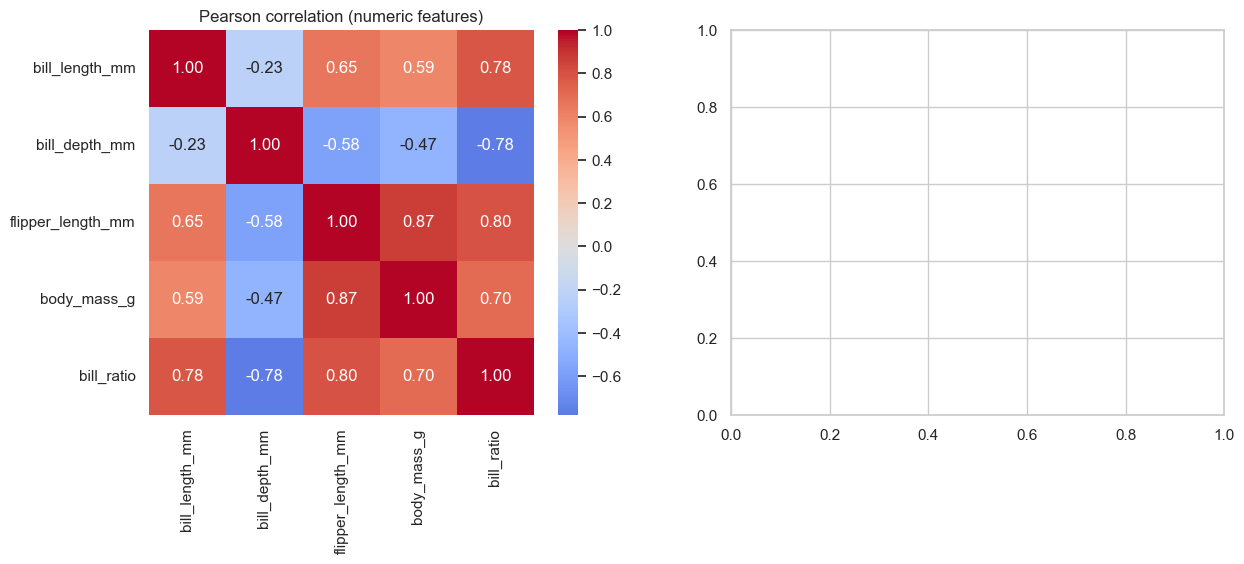

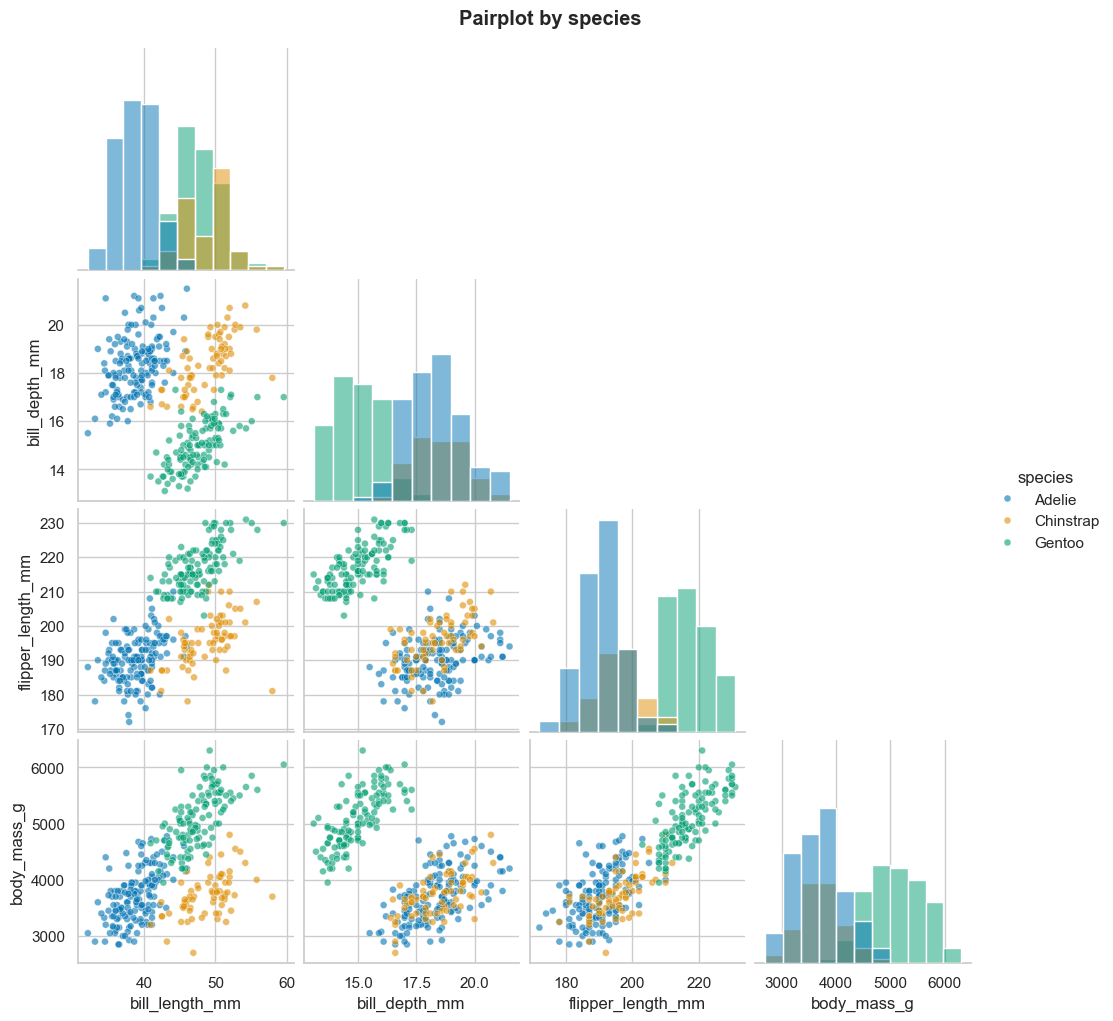

In [6]:
num_df = df[NUM]
corr = num_df.corr(method="pearson")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=axes[0])
axes[0].set_title("Pearson correlation (numeric features)")

# Highest |r| off-diagonal
pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=abs, ascending=False)
)
print("Top correlated pairs:\n", pairs.head(5))

g = sns.pairplot(
    df,
    vars=["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"],
    hue="species",
    corner=True,
    diag_kind="hist",
    plot_kws={"alpha": 0.6, "s": 25},
)
g.fig.suptitle("Pairplot by species", y=1.02, fontweight="bold")
plt.savefig("penguin_eda_pairplot.png", dpi=150, bbox_inches="tight")
plt.show()


**Multivariate takeaways:**
- **Flipper length** and **body mass** are highly correlated — expect redundancy in linear models.
- Species form **clusters** in pair space → classification should be feasible with a few measurements.
- For modeling: consider **standardizing** numeric features and checking **VIF** if using linear models (future session).


---
## Step 5 — Final EDA report (stakeholder handoff)

Copy/adapt this template into your project README or slide deck.


In [7]:
lines = [
    "# EDA Report — Palmer Penguins",
    "",
    "## Dataset",
    f"- Source: Seaborn penguins (Palmer Archipelago field data)",
    f"- Raw rows: {len(raw):,} | Analysis set (complete cases): {len(df):,}",
    f"- Columns used: {', '.join(MODEL_COLS + ['bill_ratio'])}",
    "",
    "## Quality",
    "- Missing values in raw data, concentrated in sex and bill measurements",
    f"- Action: complete-case subset ({len(raw) - len(df)} rows dropped)",
    "- No duplicate rows flagged in standard audit",
    "",
    "## Key findings",
    "1. Three species with distinct measurement clusters",
    "2. Gentoo heavier with longer flippers; bill shape separates Gentoo",
    "3. Males heavier than females within species (check segment counts)",
    "4. Flipper length and body mass strongly correlated (multicollinearity risk)",
    "5. Island associated with species (confounding risk)",
    "",
    "## Hypotheses for modeling",
    "- H1: Species predictable from bill + flipper + mass",
    "- H2: Sex adds signal within species for mass-related targets",
    "- H3: Bill ratio may help species ID",
    "",
    "## Recommended next steps",
    "- Document imputation vs complete-case for missing sex",
    "- Scale numeric features; consider bill_ratio",
    "- Stratified split by species; baseline classifier next",
    "",
    "## Artifacts saved",
    "- penguin_eda_univariate.png",
    "- penguin_eda_bivariate.png",
    "- penguin_eda_pairplot.png",
]
report = "\n".join(lines)
print(report)
Path("penguin_eda_report.md").write_text(report, encoding="utf-8")
print("\nWrote penguin_eda_report.md")


# EDA Report — Palmer Penguins

## Dataset
- Source: Seaborn penguins (Palmer Archipelago field data)
- Raw rows: 344 | Analysis set (complete cases): 333
- Columns used: species, island, sex, bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g, bill_ratio

## Quality
- Missing values in raw data, concentrated in sex and bill measurements
- Action: complete-case subset (11 rows dropped)
- No duplicate rows flagged in standard audit

## Key findings
1. Three species with distinct measurement clusters
2. Gentoo heavier with longer flippers; bill shape separates Gentoo
3. Males heavier than females within species (check segment counts)
4. Flipper length and body mass strongly correlated (multicollinearity risk)
5. Island associated with species (confounding risk)

## Hypotheses for modeling
- H1: Species predictable from bill + flipper + mass
- H2: Sex adds signal within species for mass-related targets
- H3: Bill ratio may help species ID

## Recommended next steps
- Document i

---
## 🧪 Reflection exercises

1. Re-run the audit on **raw** data only. Which column has the highest missing %? Does missingness depend on `species`?
2. Repeat bivariate scatter **without** `hue='species'`. Why is pooling misleading?
3. Drop `bill_ratio` and rebuild the correlation heatmap. What changes?
4. Split `df` into train-only EDA (80%) and confirm findings still hold — why does this matter before modeling?
5. Extend the report with **one plot you think is missing** (e.g., ECDF of body mass by species) and one new bullet finding.

---

## 📝 Session 15 Summary

| Phase | What we did |
|-------|-------------|
| **Context** | Defined questions, grain, segments |
| **Quality** | Audit table, missingness, duplicates |
| **Clean** | Complete-case analysis set + `bill_ratio` feature |
| **Univariate** | Histograms/KDE + categorical counts |
| **Bivariate** | Scatter, box/violin, segmented tables |
| **Multivariate** | Correlation + pairplot |
| **Report** | Markdown memo + saved figures |

### Key takeaways
- End-to-end EDA is **structured storytelling**, not random plotting
- **Document drops** (missing rows) as clearly as findings
- **Segment** by species/sex before interpreting pooled trends
- Deliver **artifacts**: figures + written report for the next teammate

### Key gotchas
- Small subgroups → shaky subgroup statistics
- **Island ↔ species** overlap → confounding
- High correlation → feature selection needed before linear models
- EDA on the **full dataset** including future test rows causes leakage in ML — split first in real projects

### Next Session
**Session 16**: Data Preprocessing for Machine Learning — Foundations (train/test split, encoding, scaling, sklearn Pipeline on penguins).
